
# Univariant LSTM Model

### Data Preprocessing 

In [2]:

import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score


# 1) Load + preprocess

path = "Merged_1.csv"
df = pd.read_csv(path)

# keep consistent column names
df = df.drop(['country_region', 'date.1'], axis=1, errors='ignore')
df = df.rename(columns={
    'location.1': 'Country',
    'total_deaths': 'TotalDeaths',
    'date': 'Date',
    'individualism': 'Individualism',
    'masculinity': 'Masculinity',
    'powerdistance': 'Power Distance',
    'uncertaintyavoidance': 'Uncertainty Avoidance',
    'longtermorientation': 'Long Term Orientation',
    'democracyindex2021': 'Democracy Index',
    'indulgence': 'Indulgence',
    'gdp_per_capita': 'GDP (per capita)',
    'aged_65_older': 'Aged 65 Older',
    'stringency_index': 'Stringency Index',
    'population': 'Population'
})

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.sort_values(['Country', 'Date']).reset_index(drop=True)
df['time_step'] = df.groupby('Country').cumcount()



# target: normalized cumulative deaths 
df['TotalDeaths'] = df['TotalDeaths'].fillna(0)
daily = df.groupby('Country')['TotalDeaths'].diff().fillna(0).clip(lower=0)
df['CumulativeDeaths'] = daily.groupby(df['Country']).cumsum()
df['cumulative_norm'] = df.groupby('Country')['CumulativeDeaths'].transform(
    lambda x: x / (x.max() if x.max() > 0 else 1.0)
)


In [3]:
df.columns

Index(['Country', 'TotalDeaths', 'Date', 'Individualism', 'Masculinity',
       'Power Distance', 'Indulgence', 'Uncertainty Avoidance',
       'Long Term Orientation', 'Democracy Index', 'GDP (per capita)',
       'Aged 65 Older', 'Stringency Index', 'Population',
       'retail_and_recreation_percent_change_from_baseline',
       'grocery_and_pharmacy_percent_change_from_baseline',
       'parks_percent_change_from_baseline',
       'transit_stations_percent_change_from_baseline',
       'workplaces_percent_change_from_baseline',
       'residential_percent_change_from_baseline', 'time_step',
       'CumulativeDeaths', 'cumulative_norm'],
      dtype='object')

### Model and Visualization 


Epoch 50 - Train Loss: 0.000187
Epoch 100 - Train Loss: 0.000180
Epoch 150 - Train Loss: 0.000171
Epoch 200 - Train Loss: 0.000158
Epoch 250 - Train Loss: 0.000136
Epoch 300 - Train Loss: 0.000064
Epoch 350 - Train Loss: 0.000010
Epoch 400 - Train Loss: 0.000010
Epoch 450 - Train Loss: 0.000009
Epoch 500 - Train Loss: 0.000009
Epoch 550 - Train Loss: 0.000009
Epoch 600 - Train Loss: 0.000009
Epoch 650 - Train Loss: 0.000009
Epoch 700 - Train Loss: 0.000009
Epoch 750 - Train Loss: 0.000009
Epoch 800 - Train Loss: 0.000009
Epoch 850 - Train Loss: 0.000009
Epoch 900 - Train Loss: 0.000009
Epoch 950 - Train Loss: 0.000008
Epoch 1000 - Train Loss: 0.000008
Epoch 1050 - Train Loss: 0.000008
Epoch 1100 - Train Loss: 0.000008
Epoch 1150 - Train Loss: 0.000008
Epoch 1200 - Train Loss: 0.000008
Epoch 1250 - Train Loss: 0.000008
Epoch 1300 - Train Loss: 0.000008
Epoch 1350 - Train Loss: 0.000008
Epoch 1400 - Train Loss: 0.000008
Epoch 1450 - Train Loss: 0.000008
Epoch 1500 - Train Loss: 0.000007


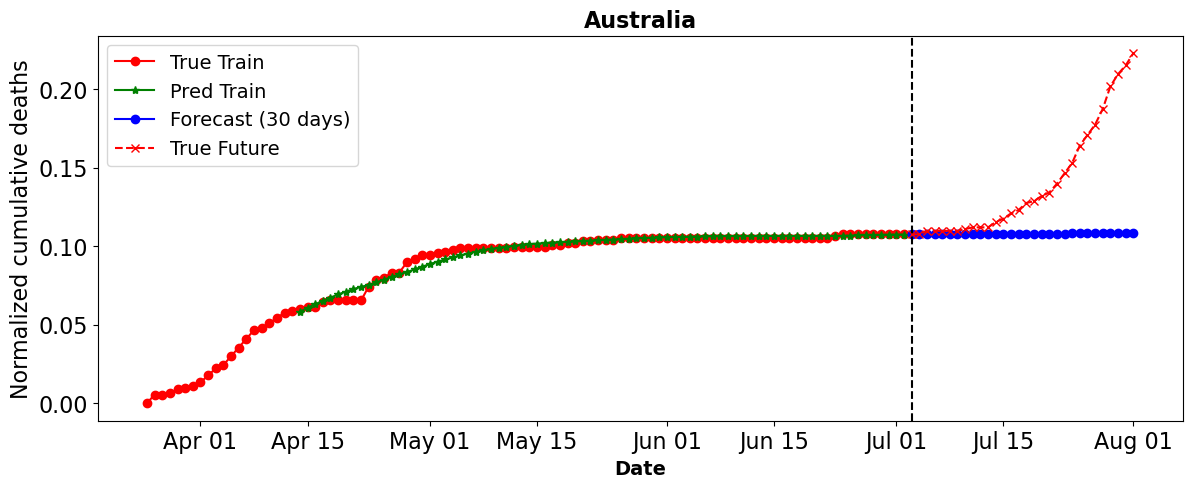

Australia — Forecast MSE: 0.002299


In [163]:

                                                        

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, r2_score

                                                         
TRAIN_DAYS = 100
FORECAST_DAYS = 30
country_name  = "Australia"   

                                                         
g = df[df['Country']==country_name].sort_values('time_step').reset_index(drop=True)
true_seq = g['cumulative_norm'].values

                                                        
train_seq = true_seq[:TRAIN_DAYS]
future_seq = true_seq[TRAIN_DAYS:TRAIN_DAYS+FORECAST_DAYS]

                                                        
def create_windows(series, input_len=20, horizon=1):
    X, y = [], []
    for i in range(len(series) - input_len - horizon + 1):
        X.append(series[i:i+input_len])
        y.append(series[i+input_len:i+input_len+horizon])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

INPUT_LEN = 20
HORIZON = 1                                               
X_train, y_train = create_windows(train_seq, input_len=INPUT_LEN, horizon=HORIZON)

X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)

                                                         
class DeathsLSTM(nn.Module):
    def __init__(self, input_len, hidden_dim=128, horizon=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, horizon)
        self.input_len = input_len

    def forward(self, x):
                                                           
        x = x.unsqueeze(-1)                                
        out, _ = self.lstm(x)                              
        h_last = out[:, -1, :]                             
        return self.fc(h_last)

model = DeathsLSTM(INPUT_LEN, hidden_dim=128, horizon=HORIZON)
opt = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

                                                           
for ep in range(2000):
    model.train()
    opt.zero_grad()
    



    pred = model(X_train_t).squeeze()
    loss = loss_fn(pred, y_train_t.squeeze())
    loss.backward()
    opt.step()
    if (ep+1) % 50 == 0:
        print(f"Epoch {ep+1} - Train Loss: {loss.item():.6f}")

                                                          
model.eval()
with torch.no_grad():
    pred_train = []
    for i in range(len(X_train_t)):
        pr = model(X_train_t[i].unsqueeze(0)).squeeze().item()
        pred_train.append(pr)

                                                           
forecast = list(train_seq[-INPUT_LEN:])  
pred_future = []
with torch.no_grad():
    for _ in range(FORECAST_DAYS):
        x_in = torch.tensor(forecast[-INPUT_LEN:], dtype=torch.float32).unsqueeze(0)
        pr = model(x_in).squeeze().item()
        forecast.append(pr)
        pred_future.append(pr)

                                                              
plt.figure(figsize=(14,5))


                                                             
plt.plot(g['Date'][:TRAIN_DAYS], train_seq, 'ro-', label="True Train")
                                                             

plt.plot(g['Date'][INPUT_LEN:TRAIN_DAYS], pred_train, 'g*-', label="Pred Train")
                                                             
plt.plot(g ['Date'][TRAIN_DAYS:TRAIN_DAYS+FORECAST_DAYS], pred_future, 'bo-', label="Forecast (30 days)")
                                                             
plt.plot(g['Date'][TRAIN_DAYS:TRAIN_DAYS+FORECAST_DAYS], future_seq, 'rx--', label="True Future")

plt.axvline(g['Date'].iloc[TRAIN_DAYS], color="k", linestyle="--")  
plt.title(country_name ,fontsize=16 ,fontweight='bold')
plt.ylabel("Normalized cumulative deaths",fontsize = 16) 
plt.xlabel('Date', fontsize=14 ,fontweight='bold')
plt.legend(fontsize = 14)
plt.grid(False)
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

                                                 

print("File saved:", f"{country_name}_deaths_forecast.csv")

plt.show()

                                                
mse = mean_squared_error(future_seq, pred_future)
r2 = r2_score(future_seq, pred_future)
print(f"{country_name} — Forecast MSE: {mse:.6f}" )


In [147]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

                                                      
true_train_targets = train_seq[INPUT_LEN:TRAIN_DAYS]

                                                      
pred_train = np.array(pred_train)

                                                      
train_mse = mean_squared_error(true_train_targets, pred_train)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(true_train_targets, pred_train)

print(f"{country_name} — Train MSE:  {train_mse:.6f}")
print(f"{country_name} — Train RMSE: {train_rmse:.6f}")
print(f"{country_name} — Train MAE:  {train_mae:.6f}")


Trinidad and Tobago — Train MSE:  0.000000
Trinidad and Tobago — Train RMSE: 0.000005
Trinidad and Tobago — Train MAE:  0.000002


In [164]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Metrics on forecast
mse = mean_squared_error(future_seq, pred_future)
rmse = np.sqrt(mse)
mae = mean_absolute_error(future_seq, pred_future)
r2 = r2_score(future_seq, pred_future)

print(f"{country_name} — Forecast MSE : {mse:.6f}")
print(f"{country_name} — Forecast RMSE: {rmse:.6f}")
print(f"{country_name} — Forecast MAE : {mae:.6f}")


Australia — Forecast MSE : 0.002299
Australia — Forecast RMSE: 0.047947
Australia — Forecast MAE : 0.032000
